【STEP 0  读取数据】
共读取 50 条书名

【STEP 1  数据清洗 & 分词（jieba）】
清洗后总词数（含重复）：147
不重复词种数：93

分词示例：
  'Python编程从入门到实践 第3版'
    → ['编程', '从入门到实践']
  'Python网络爬虫与数据分析从入门到实践'
    → ['网络爬虫', '数据分析', '从入门到实践']
  'Python完全自学教程'
    → ['自学', '教程']
  '深度学习的数学――使用Python语言'
    → ['深度学习', '数学']
  'Python+Office:轻松实现Python办公自动化'
    → ['办公自动化']

【STEP 2  词频统计 Top 20】
排名    词汇              出现次数
------------------------------
1     编程              15
2     入门              8
3     从入门到实践          5
4     深度学习            5
5     机器学习            5
6     实践              4
7     项目              4
8     网络爬虫            3
9     数据分析            3
10    从入门到精通          3
11    量化交易实战          3
12    数学              2
13    办公              2
14    实战              2
15    策略              2
16    数据科学            2
17    指南              2
18    线性代数            2
19    自学              1
20    教程              1

【STEP 3  Bigram 分析 Top 15】
排名    词对                        次数
-----------------------------------
1     编程 · 从入门到实

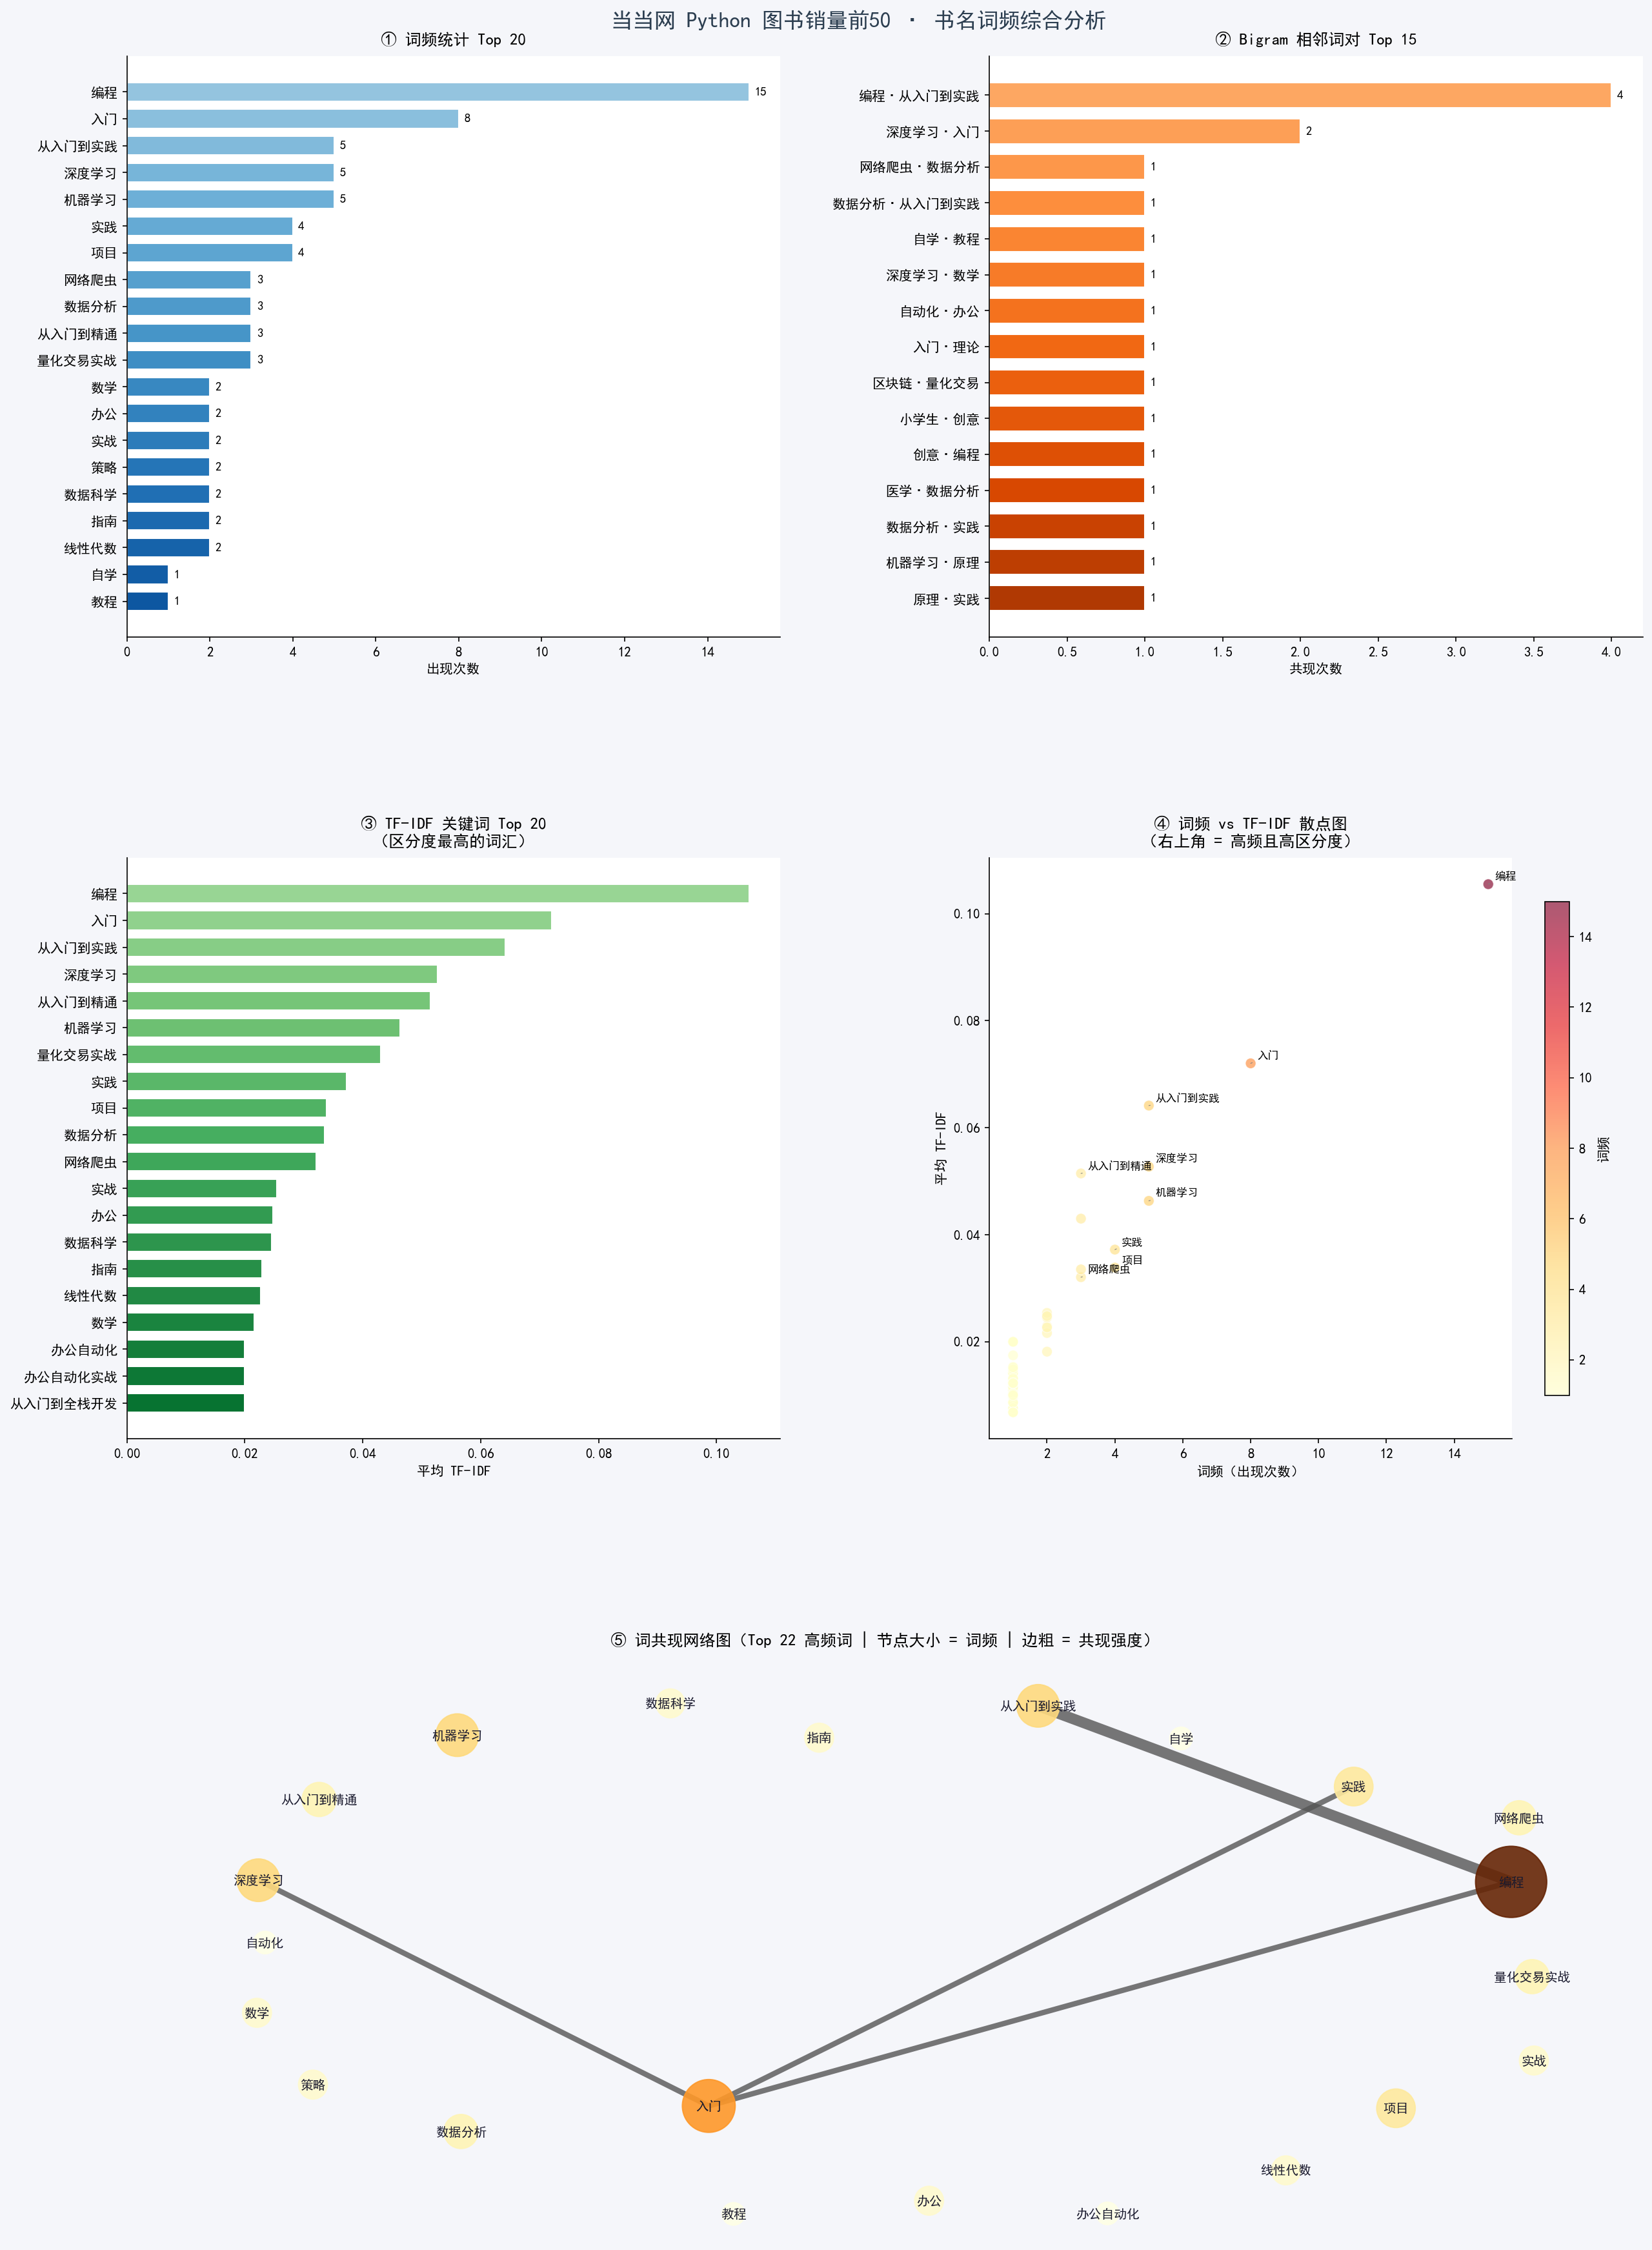


【STEP 6  词云图（可选）】
✅ 词云图已保存至：..\output\Tsk5\Python图书书名词云.png


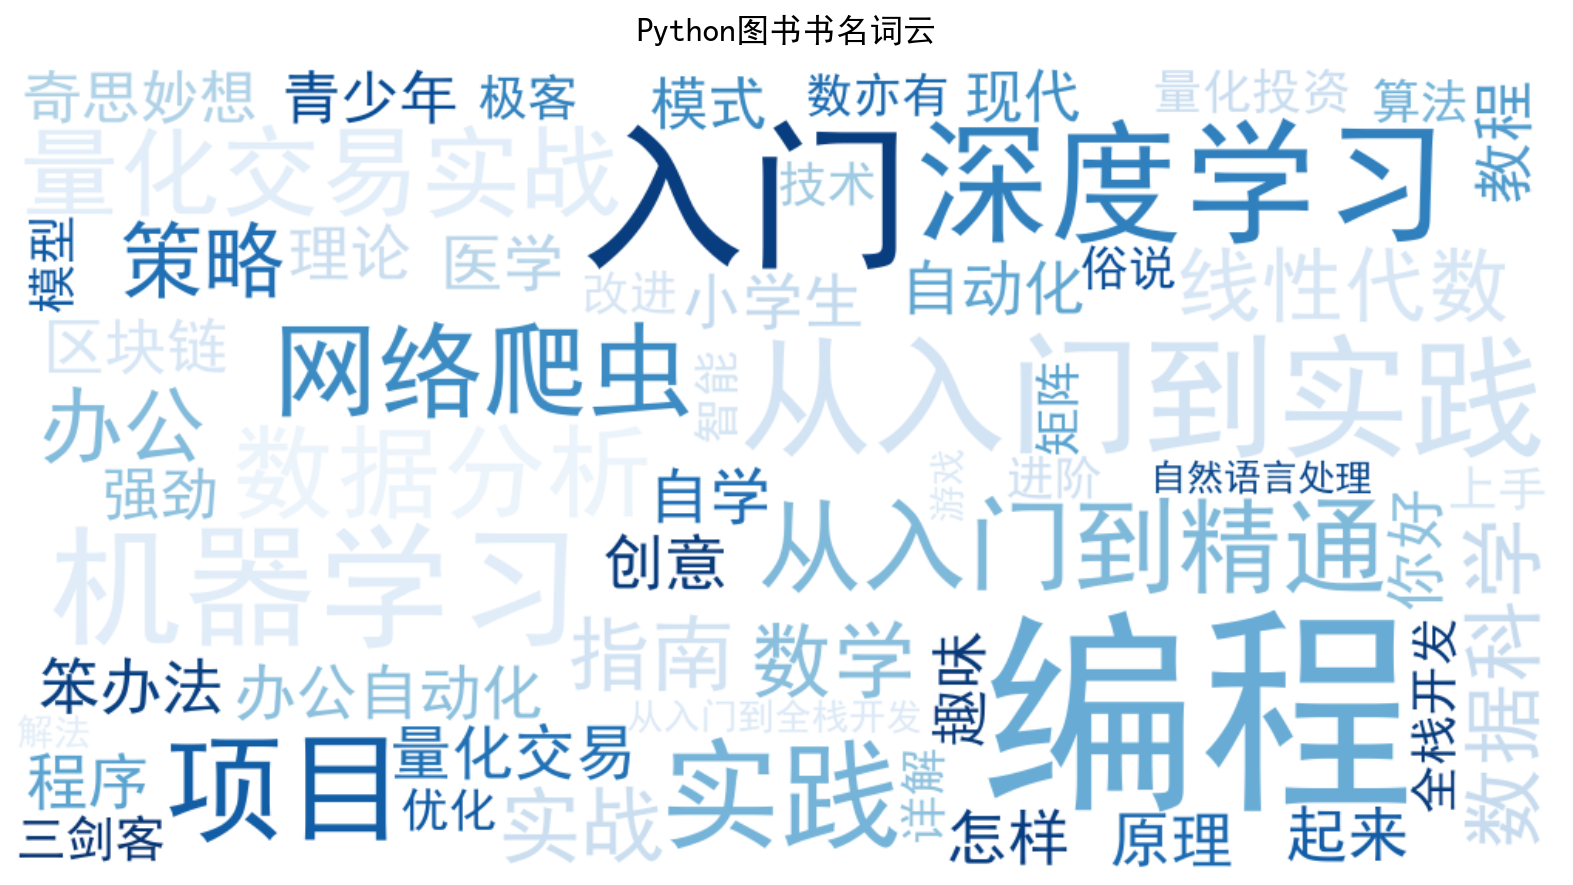


【STEP 7  摘要输出】
▶ 词频 Top 5：['编程', '入门', '从入门到实践', '深度学习', '机器学习']
▶ TF-IDF Top 5（有区分度）：['编程', '入门', '从入门到实践', '深度学习', '从入门到精通']
▶ 最常见 Bigram：['编程·从入门到实践', '深度学习·入门', '网络爬虫·数据分析']
▶ 共现网络：22 个节点，4 条边

分析完成 ✓


In [ ]:
# =============================================================
# Tsk5 当当网 Python 类图书销量前50 书名词频分析
# 蔡柏林25210110
# 分析流程：数据清洗 → 词频统计 → 柱状图 → Bigram → TF-IDF → 共现网络
# 依赖：pandas, numpy, matplotlib, scikit-learn, networkx, jieba
# 安装：pip install jieba
# 可选：wordcloud（pip install wordcloud）
# =============================================================

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import numpy as np
import re
import os
import logging
from collections import Counter
import jieba
import jieba.analyse
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from itertools import combinations
from sklearn.feature_extraction.text import TfidfVectorizer
import networkx as nx

# 关闭 jieba 日志提示
logging.getLogger("jieba").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 控制台加粗函数
def bold(s):
    return f"\033[1m{s}\033[0m"

# ── 路径配置（已修改为相对路径）─────────────────────────────────────
CSV_PATH   = r"..\data_clean\dangdang_python_books_clean.csv"
OUTPUT_DIR = r"..\output\Tsk5"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════
# 工具：中文字体检测
# ════════════════════════════════════════════════════════════════
def get_chinese_font():
    candidates = ["SimHei", "Microsoft YaHei", "PingFang SC",
                  "WenQuanYi Micro Hei", "Noto Sans CJK SC"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    for p in [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc",
              "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"]:
        if os.path.exists(p):
            fm.fontManager.addfont(p)
            return fm.FontProperties(fname=p).get_name()
    return None

FONT_NAME = get_chinese_font()
if FONT_NAME:
    matplotlib.rcParams["font.family"] = FONT_NAME
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 150

# ════════════════════════════════════════════════════════════════
# STEP 0  读取数据
# ════════════════════════════════════════════════════════════════
print("【STEP 0  读取数据】")

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["书名"]).reset_index(drop=True)
titles_raw = df["书名"].tolist()
print(f"共读取 {len(titles_raw)} 条书名")

# ════════════════════════════════════════════════════════════════
# STEP 1  数据清洗 & 分词（jieba 精确模式）
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 1  数据清洗 & 分词（jieba）】")

DOMAIN_WORDS = [
    "深度学习", "机器学习", "数据分析", "数据科学", "网络爬虫", "办公自动化",
    "量化交易", "量化投资", "自然语言处理", "人工智能", "线性代数", "强化学习",
    "全栈开发", "数据可视化", "区块链", "青少年编程", "小学生编程", "编程思维",
    "从入门到实践", "从入门到精通", "从入门到全栈开发", "量化交易实战",
    "办公自动化实战", "模式识别", "音乐信号处理",
]
for w in DOMAIN_WORDS:
    jieba.add_word(w, freq=1000)

STOPWORDS = {
    "的", "了", "和", "与", "或", "及", "等", "从", "到", "用", "在", "是", "有", "为", "让",
    "向", "你", "我", "他", "这", "那", "之", "但", "都", "把", "被", "所", "以", "上", "下",
    "版", "第", "本", "册", "书", "图书", "全", "新", "原书", "全彩版", "语言", "日本",
    "附赠", "配套", "视频", "源代码", "课件", "速查", "地图", "路线图", "教学", "教学版",
    "微课", "很简单",
    "简单", "完全", "快速", "轻松", "高效", "深入", "实用", "全面", "权威", "经典", "最新",
    "使用", "基于", "实现", "学习", "掌握", "提升", "带你", "借助", "升级",
    "python", "Python",
}

def clean_title(title: str) -> str:
    title = title.split("，")[0].split(",")[0]
    title = re.sub(r"[（(【\[].+?[）)\]】]", " ", title)
    title = re.sub(r"[A-Za-z0-9+:：\-\+\*\.]+", " ", title)
    title = re.sub(r"[^\u4e00-\u9fa5\s]", " ", title)
    return title.strip()

def tokenize(text: str) -> list:
    return [w for w in jieba.cut(text, cut_all=False) if len(w) >= 2]

all_words = []
title_word_lists = []
for title in titles_raw:
    cleaned  = clean_title(title)
    words    = tokenize(cleaned)
    filtered = [w for w in words if w not in STOPWORDS]
    all_words.extend(filtered)
    title_word_lists.append(filtered)

print(f"清洗后总词数（含重复）：{len(all_words)}")
print(f"不重复词种数：{len(set(all_words))}")
print("\n分词示例：")
for t, wl in list(zip(titles_raw, title_word_lists))[:5]:
    print(f"  {t[:35]!r}")
    print(f"    → {wl}")
	
# ════════════════════════════════════════════════════════════════
# STEP 2  词频统计（Counter）
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 2  词频统计 Top 20】")

word_counter = Counter(all_words)
top20 = word_counter.most_common(20)

print(f"{'排名':<5} {'词汇':<15} {'出现次数'}")
print("-" * 30)
for rank, (word, count) in enumerate(top20, 1):
    print(f"{rank:<5} {word:<15} {count}")
	
# ════════════════════════════════════════════════════════════════
# STEP 3  Bigram 分析（相邻词对）
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 3  Bigram 分析 Top 15】")

bigrams = []
for wl in title_word_lists:
    for i in range(len(wl) - 1):
        bigrams.append((wl[i], wl[i + 1]))

bigram_counter = Counter(bigrams)
top_bigrams = bigram_counter.most_common(15)

print(f"{'排名':<5} {'词对':<25} {'次数'}")
print("-" * 35)
for rank, (pair, cnt) in enumerate(top_bigrams, 1):
    print(f"{rank:<5} {' · '.join(pair):<25} {cnt}")
	
# ════════════════════════════════════════════════════════════════
# STEP 4  TF-IDF 分析
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 4  TF-IDF 分析 Top 20】")

corpus = [" ".join(wl) if wl else "空" for wl in title_word_lists]
vectorizer = TfidfVectorizer(
    token_pattern=r"[\u4e00-\u9fa5]{2,}",
    min_df=1,
    max_df=0.90,
)
tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()

tfidf_df = pd.DataFrame({
    "词汇": feature_names,
    "平均TF-IDF": mean_tfidf
}).sort_values("平均TF-IDF", ascending=False)

print(tfidf_df.head(20).to_string(index=False))

# ════════════════════════════════════════════════════════════════
# STEP 5  综合可视化（5合1图表）
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 5  生成综合可视化图表】")

fig = plt.figure(figsize=(18, 24))
fig.patch.set_facecolor("#f5f6fa")
fig.suptitle("当当网 Python 图书销量前50 · 书名词频综合分析",
             fontsize=16, fontweight="bold", y=0.99, color="#2c3e50")

# ── 子图①：词频 Top 20 柱状图 ──────────────────────────────────
ax1 = fig.add_subplot(3, 2, 1)
ax1.set_facecolor("white")
wl_ = [w for w, _ in top20]
cl_ = [c for _, c in top20]
blues = plt.cm.Blues(np.linspace(0.4, 0.85, len(wl_)))
b1 = ax1.barh(wl_[::-1], cl_[::-1], color=blues[::-1], height=0.7, edgecolor="white")
ax1.bar_label(b1, padding=4, fontsize=9)
ax1.set_xlabel("出现次数", fontsize=10)
ax1.set_title("① 词频统计 Top 20", fontsize=12, fontweight="bold", pad=8)
ax1.spines[["top", "right"]].set_visible(False)

# ── 子图②：Bigram 柱状图 ───────────────────────────────────────
ax2 = fig.add_subplot(3, 2, 2)
ax2.set_facecolor("white")
bg_l = [f"{a}·{b}" for (a, b), _ in top_bigrams]
bg_c = [c for _, c in top_bigrams]
oranges = plt.cm.Oranges(np.linspace(0.4, 0.85, len(bg_l)))
b2 = ax2.barh(bg_l[::-1], bg_c[::-1], color=oranges[::-1], height=0.7, edgecolor="white")
ax2.bar_label(b2, padding=4, fontsize=9)
ax2.set_xlabel("共现次数", fontsize=10)
ax2.set_title("② Bigram 相邻词对 Top 15", fontsize=12, fontweight="bold", pad=8)
ax2.spines[["top", "right"]].set_visible(False)

# ── 子图③：TF-IDF Top 20 柱状图 ───────────────────────────────
ax3 = fig.add_subplot(3, 2, 3)
ax3.set_facecolor("white")
top20_tfidf = tfidf_df.head(20)
tw = top20_tfidf["词汇"].tolist()
ts = top20_tfidf["平均TF-IDF"].tolist()
greens = plt.cm.Greens(np.linspace(0.4, 0.85, len(tw)))
ax3.barh(tw[::-1], ts[::-1], color=greens[::-1], height=0.7, edgecolor="white")
ax3.set_xlabel("平均 TF-IDF", fontsize=10)
ax3.set_title("③ TF-IDF 关键词 Top 20\n（区分度最高的词汇）",
              fontsize=12, fontweight="bold", pad=8)
ax3.spines[["top", "right"]].set_visible(False)

# ── 子图④：词频 vs TF-IDF 散点图 ──────────────────────────────
ax4 = fig.add_subplot(3, 2, 4)
ax4.set_facecolor("white")
all_vocab = list(set(all_words))
freq_a  = [word_counter[w] for w in all_vocab]
tdict   = dict(zip(feature_names, mean_tfidf))
tfidf_a = [tdict.get(w, 0) for w in all_vocab]
sc = ax4.scatter(freq_a, tfidf_a, alpha=0.65, c=freq_a, cmap="YlOrRd",
                 s=60, edgecolor="white", linewidth=0.5)
plt.colorbar(sc, ax=ax4, label="词频", shrink=0.85)
highlight = set([w for w, _ in top20[:8]] + tfidf_df["词汇"].head(5).tolist())
for w in highlight:
    if w in all_vocab:
        i = all_vocab.index(w)
        ax4.annotate(w, (freq_a[i], tfidf_a[i]), fontsize=8,
                     xytext=(5, 3), textcoords="offset points",
                     arrowprops=dict(arrowstyle="-", lw=0.5, color="gray"))
ax4.set_xlabel("词频（出现次数）", fontsize=10)
ax4.set_ylabel("平均 TF-IDF", fontsize=10)
ax4.set_title("④ 词频 vs TF-IDF 散点图\n（右上角 = 高频且高区分度）",
              fontsize=12, fontweight="bold", pad=8)
ax4.spines[["top", "right"]].set_visible(False)

# ── 子图⑤：词共现网络图 ────────────────────────────────────────
ax5 = fig.add_subplot(3, 1, 3)
ax5.set_facecolor("white")
topN = {w for w, _ in word_counter.most_common(22)}
co_c = Counter()
for wl in title_word_lists:
    fl = [w for w in wl if w in topN]
    for pair in combinations(set(fl), 2):
        co_c[tuple(sorted(pair))] += 1

G = nx.Graph()
for (w1, w2), wt in co_c.items():
    if wt >= 2:
        G.add_edge(w1, w2, weight=wt)
for w in topN:
    if w not in G:
        G.add_node(w)

nf = [word_counter[n] for n in G.nodes()]
ns = [f * 180 + 100 for f in nf]
ew = [G[u][v]["weight"] * 2 for u, v in G.edges()]
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw_networkx_nodes(G, pos, node_size=ns, node_color=nf,
                       cmap=plt.cm.YlOrBr, alpha=0.9, ax=ax5, vmin=1)
nx.draw_networkx_edges(G, pos, width=ew, edge_color="#555555", alpha=0.8, ax=ax5)
nx.draw_networkx_labels(G, pos, font_size=9.5, ax=ax5,
                        font_family=FONT_NAME or "sans-serif", font_color="#1a1a2e")
ax5.set_title(
    "⑤ 词共现网络图（Top 22 高频词 | 节点大小 = 词频 | 边粗 = 共现强度）",
    fontsize=12, fontweight="bold", pad=10)
ax5.axis("off")

plt.subplots_adjust(left=0.08, right=0.95, top=0.97, bottom=0.03,
                    hspace=0.38, wspace=0.32)

# ========== 新增：保存综合图表（保留 plt.show）==========
save_path = os.path.join(OUTPUT_DIR, "Python图书词频综合分析.png")
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"✅ 综合图表已保存至：{save_path}")
# ======================================================

plt.show()  # ← 直接展示，不改动

# ════════════════════════════════════════════════════════════════
# STEP 6  词云图（可选）
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 6  词云图（可选）】")

import os
import matplotlib.pyplot as plt
try:
    from wordcloud import WordCloud

    font_path = None
    for p in [r"C:\Windows\Fonts\simhei.ttf", r"C:\Windows\Fonts\msyh.ttc",
              "/usr/share/fonts/truetype/wqy/wqy-microhei.ttc"]:
        if os.path.exists(p):
            font_path = p
            break

    wc = WordCloud(
        font_path=font_path,
        width=1000, height=520,
        background_color="white",
        colormap="Blues",
        max_words=60,
        min_font_size=10,
    ).generate_from_frequencies(dict(word_counter))

    fig2, ax = plt.subplots(figsize=(13, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("Python图书书名词云", fontsize=16, fontweight="bold", pad=12)
    plt.tight_layout()

    # ========== 新增：保存词云图（保留 plt.show）==========
    wc_save_path = os.path.join(OUTPUT_DIR, "Python图书书名词云.png")
    plt.savefig(wc_save_path, dpi=150, bbox_inches='tight')
    print(f"✅ 词云图已保存至：{wc_save_path}")
    # ====================================================

    plt.show()

except ImportError:
    print("[跳过] wordcloud 未安装：pip install wordcloud")

# ════════════════════════════════════════════════════════════════
# STEP 7  摘要输出
# ════════════════════════════════════════════════════════════════
print("")
print("【STEP 7  摘要输出】")
print(f"▶ 词频 Top 5：{[w for w,_ in top20[:5]]}")
print(f"▶ TF-IDF Top 5（有区分度）：{tfidf_df['词汇'].head(5).tolist()}")
print(f"▶ 最常见 Bigram：{[f'{a}·{b}' for (a,b),_ in top_bigrams[:3]]}")
print(f"▶ 共现网络：{G.number_of_nodes()} 个节点，{G.number_of_edges()} 条边")
print("\n分析完成 ✓")